# EDA Familia Casquillo 10 — Frisa García
## Análisis Exploratorio de Una Sola Familia

**Proyecto:** Reto Frisa – Tecnológico de Monterrey · 2026  
**Familia analizada:** Casquillo 10 (n = 285 registros)  
**Integrantes:** Paola Mireles Ochoa A01753439, Fernando Juárez Vargas A00841666 , Mar Andrea Fernández Higuera A00227571


---

## Introducción

La familia **Casquillo 10** es la más numerosa del dataset de la planta García, con 285 registros tras la limpieza. Pertenece a la categoría geométrica de *casquillo* (ARC/ARX), lo que implica que son anillos con altura significativamente mayor que el espesor de pared. En este caso, todos los registros corresponden al tipo **ARX** (anillo de preforma extruida), la geometría más compleja y de mayor riesgo dimensional dentro del portafolio de Frisa, fabricada exclusivamente en la planta García en las roladoras R5 y R6. Las piezas tienen diámetros exteriores entre 521 y 1,346 mm y alturas entre 654 y 1,549 mm, lo que las clasifica como componentes de gran tamaño destinados a aplicaciones industriales de alta responsabilidad.

Por ser una familia ARX, su envolvente mínima establecida por Frisa es de **18 mm independientemente del diámetro exterior**, la restricción más conservadora del catálogo. Esto hace que el análisis de exceso en Casquillo 10 sea particularmente relevante: cualquier sobreentrega sistemática por encima de ese mínimo representa desperdicio real de material en un componente ya de por sí costoso.

El objetivo de este análisis es desarrollar intuición profunda sobre el comportamiento del proceso en esta familia antes de generalizar al dataset completo: entender qué es 'normal', identificar patrones de variación, evaluar si el algoritmo de excesos está bien calibrado, y detectar oportunidades de reducción de desperdicio respaldadas por evidencia estadística.

---
## 0. Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

AZUL   = '#2E75B6'
ROJO   = '#C0392B'
VERDE  = '#27AE60'
NARANJA = '#E67E22'
GRIS   = '#7F8C8D'
MORADO = '#8E44AD'

print('Setup completo.')

Setup completo.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- CARGA ---
# Sube el CSV a Colab o ajusta la ruta:
from google.colab import drive
drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/Frisa/Grupo202_Garcia-Base-de-Datos-6-meses-Rev-1_1_.csv'

df_completo = pd.read_csv(RUTA, encoding='latin1')

# Corregir encoding de columnas
df_completo.columns = [
    c.replace('Ã©','é').replace('Ã\xad','í').replace('Ã³','ó').replace('Ã­','í')
    for c in df_completo.columns
]

# Limpiar categóricas
cat_cols = ['Industria','Tipo','Material','Roladora','Familia geométrica',
            'Rango peso','Rango DE','Calidad','Motivo','Planta']
for c in cat_cols:
    df_completo[c] = df_completo[c].astype(str).str.strip()

# Convertir numéricas con comas de miles
num_cols = ['DE Final','DI Final','Altura Final','Peso de Forja Configurado',
            'DE Forja Real 1','DE Forja Real 2','DI Forja Real 1','DI Forja Real 2',
            'Altura Forja Real 1','Altura Forja Real 2','Peso Calculado']
for c in num_cols:
    df_completo[c] = pd.to_numeric(df_completo[c].astype(str).str.replace(',',''), errors='coerce')

# Eliminar duplicados
df_completo = df_completo.drop_duplicates().reset_index(drop=True)

# Filtrar SOLO Casquillo 10
df = df_completo[df_completo['Familia geométrica'] == 'Casquillo 10'].copy().reset_index(drop=True)

print(f'Dataset Casquillo 10: {len(df)} registros, {len(df.columns)} columnas')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Casquillo 10: 285 registros, 40 columnas


,ï»¿Orden,N Cliente,Industria,Tipo,Material,Roladora,DE Final,DI Final,Altura Final,Exceso DE configurado,...,Altura Exceso Real 2,Peso Calculado,% Pesos,Relacion E/A Finales,Familia geométrica,Rango peso,Rango DE,Calidad,Motivo,Planta
0,832243.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,965.0,41.0,...,79.0,1044.0,0.43,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
1,832242.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,813.0,52.0,...,77.0,999.0,0.25,0.05,Casquillo 10,De 750 a 1000kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
2,832243.0,190.0,N/D,ARX,Acero,R5,521.0,432.0,965.0,41.0,...,95.0,1032.0,-0.78,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a


In [ ]:
# Variables derivadas
df['Exceso_DE_Real']  = (df['DE Exceso Real 1']  + df['DE Exceso Real 2'])  / 2
df['Exceso_DI_Real']  = (df['DI Exceso Real 1']  + df['DI Exceso Real 2'])  / 2
df['Exceso_Alt_Real'] = (df['Altura Exceso Real 1'] + df['Altura Exceso Real 2']) / 2

df['Brecha_DE']  = df['Exceso_DE_Real']  - df['Exceso DE configurado']
df['Brecha_DI']  = df['Exceso_DI_Real']  - df['Exceso DI Configurado']
df['Brecha_Alt'] = df['Exceso_Alt_Real'] - df['Exceso Configurado Altura']

df['Diff_DE']  = df['DE Exceso Real 1']  - df['DE Exceso Real 2']
df['Diff_DI']  = df['DI Exceso Real 1']  - df['DI Exceso Real 2']
df['Diff_Alt'] = df['Altura Exceso Real 1'] - df['Altura Exceso Real 2']

df['Ovalamiento_abs'] = df['Ovalamiento'].abs()

print('Variables derivadas creadas.')
df[['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real',
    'Brecha_DE','Brecha_DI','Brecha_Alt']].describe().round(2)

Variables derivadas creadas.


,Exceso_DE_Real,Exceso_DI_Real,Exceso_Alt_Real,Brecha_DE,Brecha_DI,Brecha_Alt
count,285.00,285.00,285.00,285.00,285.00,285.00
mean,44.07,38.24,70.54,2.36,-4.40,11.00
std,8.56,7.78,20.23,6.02,5.83,23.61
min,23.00,14.50,25.50,-14.00,-30.50,-152.00
25%,38.00,34.00,61.50,-2.00,-7.50,3.50
50%,44.00,39.00,67.00,2.00,-4.50,10.50
75%,50.50,42.50,73.50,6.50,-1.00,17.00
max,84.50,92.00,167.50,16.50,9.50,110.50


---
## Parte 1: Variación — ¿Cómo se Comporta el Proceso en Casquillo 10?

> **Objetivo:** Entender qué es 'normal' para esta familia antes de hacer comparaciones.

### 1.1 Distribución de excesos reales en las tres dimensiones

**Pregunta:** ¿Cómo se distribuyen los excesos reales en DE, DI y Altura? ¿Son simétricos? ¿Hay múltiples picos que sugieran subpoblaciones mezcladas?

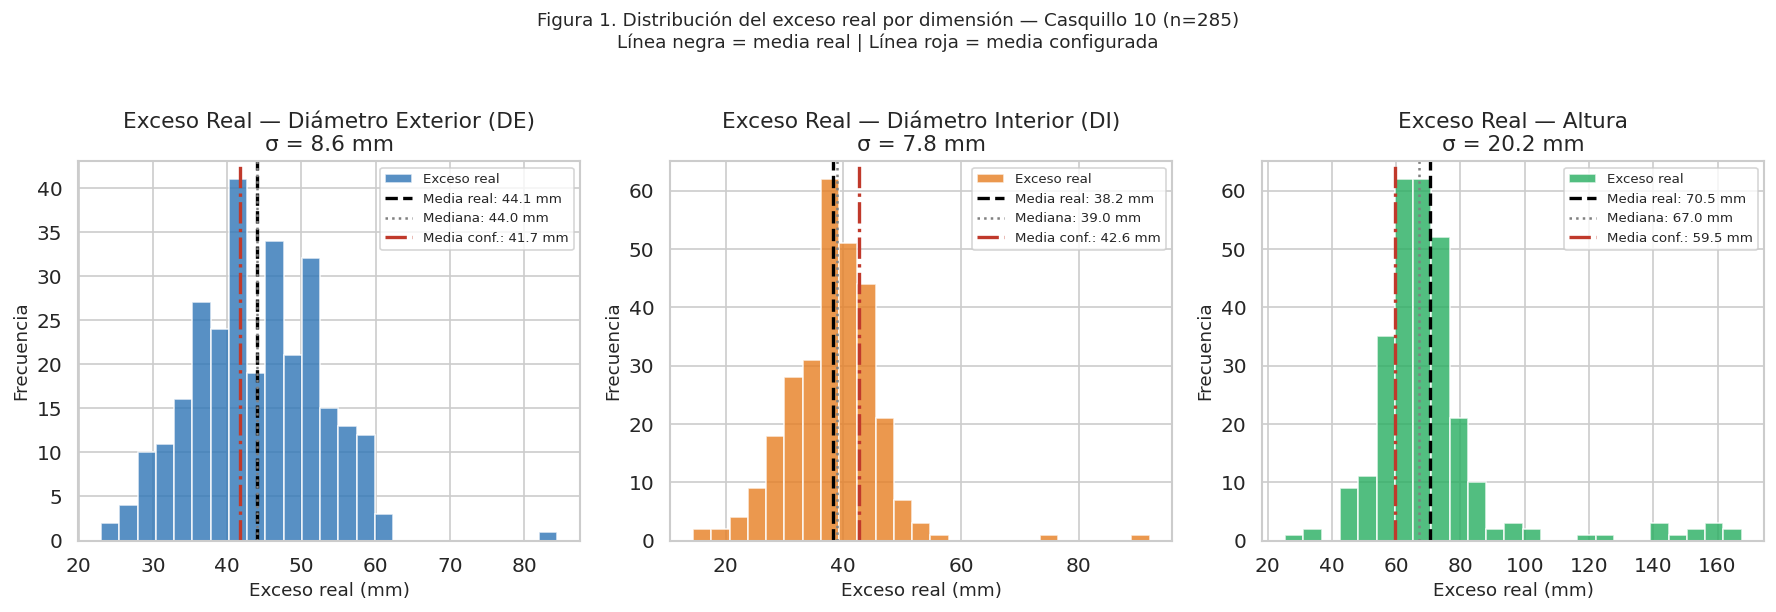

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datos_dim = [
    ('Exceso_DE_Real',  'Exceso DE configurado',     'Diámetro Exterior (DE)', AZUL),
    ('Exceso_DI_Real',  'Exceso DI Configurado',     'Diámetro Interior (DI)', NARANJA),
    ('Exceso_Alt_Real', 'Exceso Configurado Altura', 'Altura',                  VERDE),
]

for ax, (real_col, conf_col, nombre, color) in zip(axes, datos_dim):
    ax.hist(df[real_col], bins=25, color=color, alpha=0.8, edgecolor='white', label='Exceso real')
    ax.axvline(df[real_col].mean(),   color='black', lw=2,   linestyle='--',
               label=f'Media real: {df[real_col].mean():.1f} mm')
    ax.axvline(df[real_col].median(), color='gray',  lw=1.5, linestyle=':',
               label=f'Mediana: {df[real_col].median():.1f} mm')
    ax.axvline(df[conf_col].mean(),   color=ROJO,    lw=2,   linestyle='-.',
               label=f'Media conf.: {df[conf_col].mean():.1f} mm')
    ax.set_title(f'Exceso Real — {nombre}\nσ = {df[real_col].std():.1f} mm')
    ax.set_xlabel('Exceso real (mm)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Figura 1. Distribución del exceso real por dimensión — Casquillo 10 (n=285)\n'
             'Línea negra = media real | Línea roja = media configurada', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('c10_fig1_distribuciones.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Tabla comparativa de estadísticos
resumen = pd.DataFrame({
    'Dimensión': ['DE', 'DI', 'Altura'],
    'Exceso conf. promedio (mm)': [
        df['Exceso DE configurado'].mean(),
        df['Exceso DI Configurado'].mean(),
        df['Exceso Configurado Altura'].mean()
    ],
    'Exceso real promedio (mm)': [
        df['Exceso_DE_Real'].mean(),
        df['Exceso_DI_Real'].mean(),
        df['Exceso_Alt_Real'].mean()
    ],
    'Desv. estándar (mm)': [
        df['Exceso_DE_Real'].std(),
        df['Exceso_DI_Real'].std(),
        df['Exceso_Alt_Real'].std()
    ],
    'Brecha promedio (mm)': [
        df['Brecha_DE'].mean(),
        df['Brecha_DI'].mean(),
        df['Brecha_Alt'].mean()
    ],
    '% brecha positiva': [
        (df['Brecha_DE'] > 0).mean() * 100,
        (df['Brecha_DI'] > 0).mean() * 100,
        (df['Brecha_Alt'] > 0).mean() * 100
    ]
}).round(2)

display(resumen)

,Dimensión,Exceso conf. promedio (mm),Exceso real promedio (mm),Desv. estándar (mm),Brecha promedio (mm),% brecha positiva
0,DE,41.72,44.07,8.56,2.36,63.16
1,DI,42.64,38.24,7.78,-4.40,21.75
2,Altura,59.54,70.54,20.23,11.00,86.67


**Interpretación 1.1:**

Las tres dimensiones tienen comportamientos muy distintos:

- **DE (σ = 8.6 mm):** Distribución moderadamente dispersa y aproximadamente simétrica. La media real (44.1 mm) supera a la configurada (41.7 mm) en +2.4 mm. El 63% de las piezas tiene brecha positiva. El proceso entrega consistentemente *un poco más* de DE del configurado.

- **DI (σ = 7.8 mm):** Es la dimensión más precisa en términos de dispersión relativa. Sin embargo, la brecha es **negativa** (-4.4 mm en promedio), lo que significa que el proceso entrega *menos* DI del configurado en el 78% de las piezas, por lo que el algoritmo sobreestima el exceso real en DI. Esto es llamativo: aunque el proceso entrega menos que lo planeado en DI, las piezas siguen siendo buenas, lo que sugiere que el exceso configurado en DI está sobredimensionado.

- **Altura (σ = 20.2 mm):** La dimensión más variable por mucho. La brecha positiva es de +11.0 mm y el 87% de las piezas tienen sobreentrega en altura. La distribución tiene una cola larga a la derecha (máximo de 167.5 mm vs. configurado máximo de 203 mm). **Esta es la mayor oportunidad de reducción de exceso en Casquillo 10.**

Hipótesis sobre el patrón: la alta variabilidad en Altura es consistente con el proceso físico de los ARX, ya que son piezas muy altas (654–1,549 mm) donde pequeñas variaciones en la velocidad de avance axial de la roladora se amplifican en términos absolutos. La dimensión radial (DE, DI) es más controlable porque la roladora ejerce fuerza continua en esa dirección.

### 1.2 Detección y decisión sobre outliers

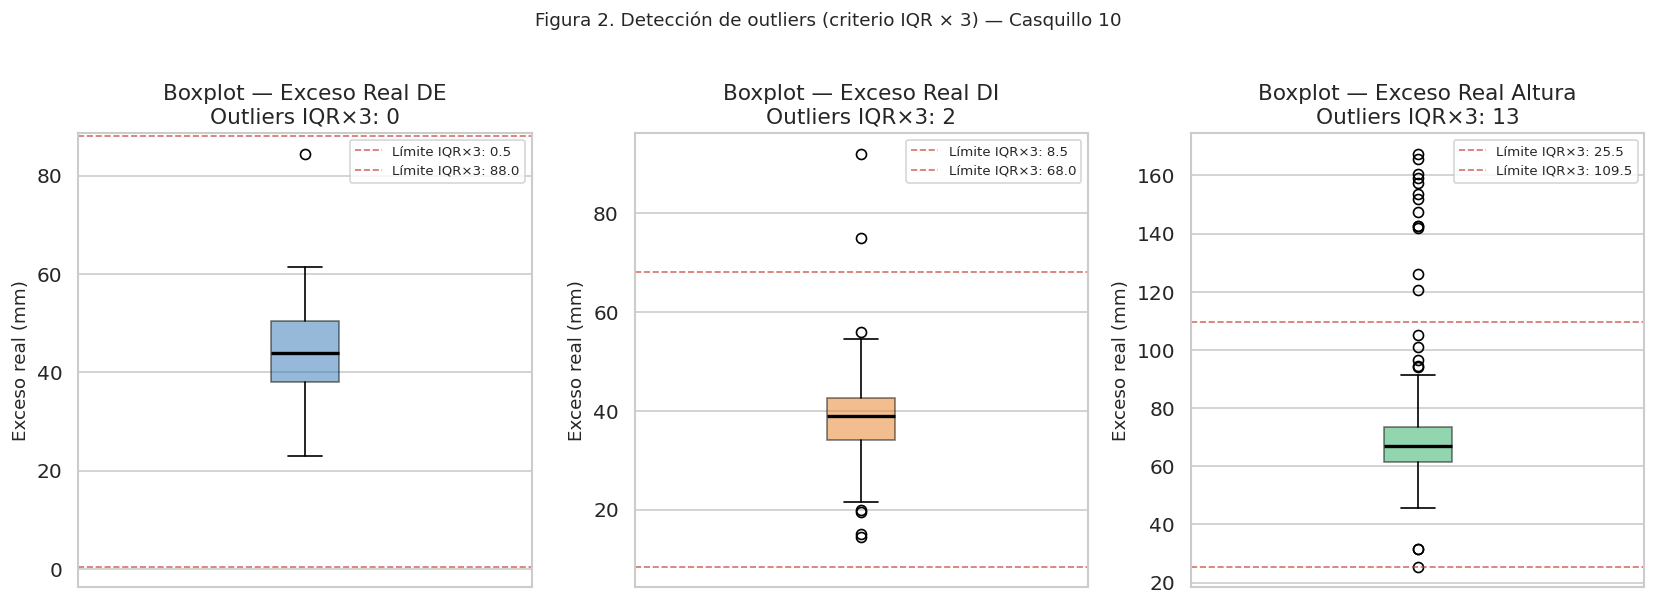

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, nombre, color) in zip(axes, [
    ('Exceso_DE_Real',  'DE',     AZUL),
    ('Exceso_DI_Real',  'DI',     NARANJA),
    ('Exceso_Alt_Real', 'Altura', VERDE),
]):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', lw=2),
               flierprops=dict(marker='o', color=ROJO, markersize=6))
    ax.axhline(lower, color=ROJO, linestyle='--', lw=1, alpha=0.7, label=f'Límite IQR×3: {lower:.1f}')
    ax.axhline(upper, color=ROJO, linestyle='--', lw=1, alpha=0.7, label=f'Límite IQR×3: {upper:.1f}')
    ax.set_title(f'Boxplot — Exceso Real {nombre}\nOutliers IQR×3: {len(outliers)}')
    ax.set_ylabel('Exceso real (mm)')
    ax.set_xticks([])
    ax.legend(fontsize=8)

fig.suptitle('Figura 2. Detección de outliers (criterio IQR × 3) — Casquillo 10', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('c10_fig2_outliers.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Inspeccionar los outliers de Altura (los más numerosos: 13)
Q1_alt = df['Exceso_Alt_Real'].quantile(0.25)
Q3_alt = df['Exceso_Alt_Real'].quantile(0.75)
IQR_alt = Q3_alt - Q1_alt
outliers_alt = df[(df['Exceso_Alt_Real'] < Q1_alt - 3*IQR_alt) |
                  (df['Exceso_Alt_Real'] > Q3_alt + 3*IQR_alt)]

print(f'Outliers en Exceso_Alt_Real (IQR×3): {len(outliers_alt)} piezas')
print(f'Rango de outliers: {outliers_alt["Exceso_Alt_Real"].min():.1f} – {outliers_alt["Exceso_Alt_Real"].max():.1f} mm')
print()
display(outliers_alt[['Orden','Tipo','Roladora','DE Final','Altura Final',
                        'Exceso Configurado Altura','Exceso_Alt_Real',
                        'Brecha_Alt','Calidad','Motivo']].sort_values('Exceso_Alt_Real', ascending=False))

Outliers en Exceso_Alt_Real (IQR×3): 13 piezas
Rango de outliers: 120.5 – 167.5 mm



,Orden,Tipo,Roladora,DE Final,Altura Final,Exceso Configurado Altura,Exceso_Alt_Real,Brecha_Alt,Calidad,Motivo
18,822197,ARX,R5,530,1200,100,167.5,67.5,Pieza buena,Pieza buena
58,811923,ARX,R5,576,1300,55,165.5,110.5,Pieza buena,Pieza buena
77,811920,ARX,R5,576,1300,55,160.5,105.5,Pieza buena,Pieza buena
51,811920,ARX,R5,576,1300,55,159.0,104.0,Pieza buena,Pieza buena
42,811926,ARX,R5,576,1300,55,157.5,102.5,Pieza buena,Pieza buena
60,811929,ARX,R5,576,1300,55,153.5,98.5,Reproceso,Cascaras / Pozos
48,811917,ARX,R5,576,1300,55,152.0,97.0,Pieza buena,Pieza buena
40,811917,ARX,R5,576,1300,55,147.5,92.5,Pieza buena,Pieza buena
86,811929,ARX,R5,576,1300,55,142.5,87.5,Pieza buena,Pieza buena
163,826499,ARX,R5,580,1220,110,142.5,32.5,Pieza buena,Pieza buena


**Decisión sobre outliers:**

Se detectaron **0 outliers en DE, 2 en DI y 13 en Altura** con el criterio IQR × 3.

Al inspeccionar los outliers de Altura, se observa que:
- Tienen dimensiones finales reales (Altura Final entre 654 y 1,549 mm), lo que confirma que son piezas físicamente existentes — no errores de captura.
- Sus excesos configurados son coherentes con el rango de la familia.
- La mayoría son piezas buenas, lo que indica que el proceso simplemente produjo más altura de la esperada en esas piezas.

**Decisión**: Se conservan todos los outliers.

**Criterio industrial**: en manufactura de forja, piezas de mayor tamaño o lotes con condiciones de temperatura distintas pueden producir excesos reales significativamente más altos. Eliminarlos sesgaría la estimación del desperdicio potencial a la baja.

### 1.3 Ovalamiento: ¿qué tan circular es Casquillo 10?

**Pregunta:** ¿Esta familia es más o menos estable geométricamente que el promedio del dataset?

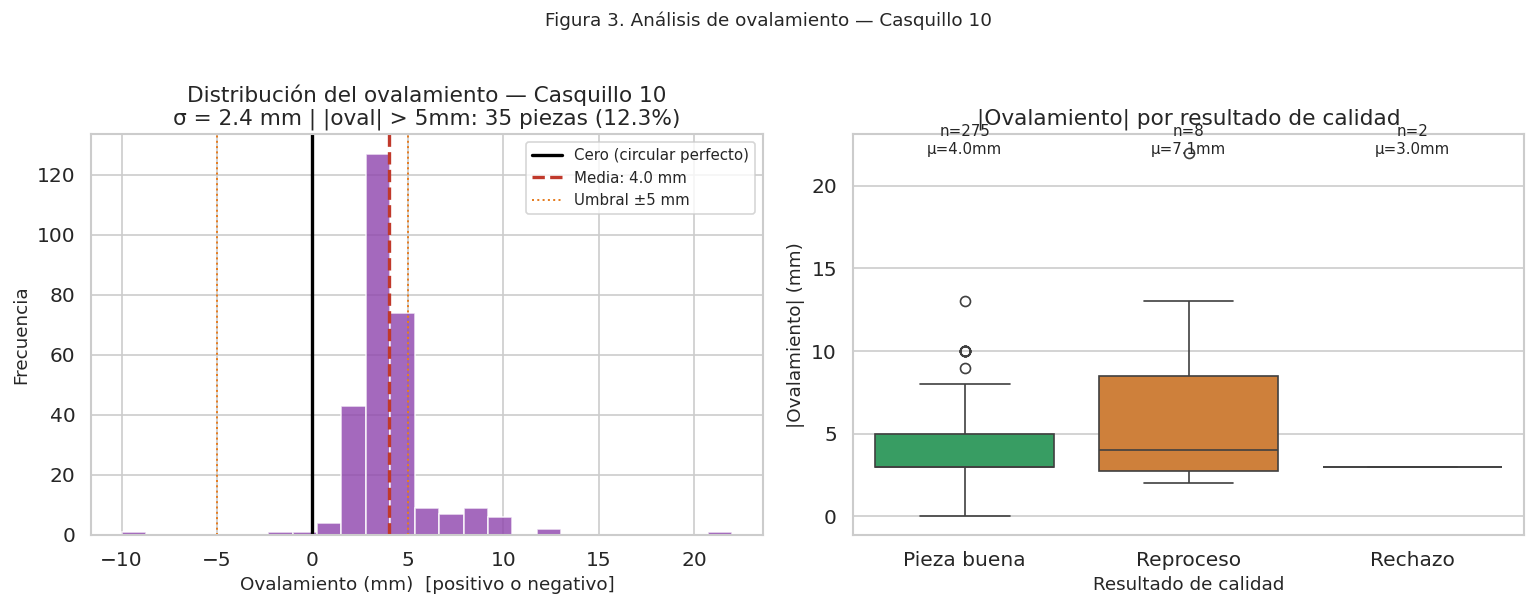

Prevalencia de ovalamiento:
  |Ovalamiento| >  5 mm:  35 piezas (12.3%)
  |Ovalamiento| > 10 mm:   3 piezas (1.1%)
  |Ovalamiento| > 15 mm:   1 piezas (0.4%)
  |Ovalamiento| > 20 mm:   1 piezas (0.4%)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de ovalamiento
ax1.hist(df['Ovalamiento'], bins=25, color=MORADO, alpha=0.8, edgecolor='white')
ax1.axvline(0,                     color='black', lw=2,   linestyle='-',  label='Cero (circular perfecto)')
ax1.axvline(df['Ovalamiento'].mean(), color=ROJO, lw=2,   linestyle='--', label=f'Media: {df["Ovalamiento"].mean():.1f} mm')
ax1.axvline(5,  color=NARANJA, lw=1.2, linestyle=':', label='Umbral ±5 mm')
ax1.axvline(-5, color=NARANJA, lw=1.2, linestyle=':')
ax1.set_title(f'Distribución del ovalamiento — Casquillo 10\n'
              f'σ = {df["Ovalamiento"].std():.1f} mm | |oval| > 5mm: {(df["Ovalamiento_abs"]>5).sum()} piezas ({(df["Ovalamiento_abs"]>5).mean()*100:.1f}%)')
ax1.set_xlabel('Ovalamiento (mm)  [positivo o negativo]')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

# Boxplot ovalamiento por calidad
orden_cal = ['Pieza buena','Reproceso','Rechazo']
paleta_cal = {'Pieza buena': VERDE, 'Reproceso': NARANJA, 'Rechazo': ROJO}
sns.boxplot(data=df, x='Calidad', y='Ovalamiento_abs',
            order=[c for c in orden_cal if c in df['Calidad'].unique()],
            palette=paleta_cal, ax=ax2)
ax2.set_title('|Ovalamiento| por resultado de calidad')
ax2.set_xlabel('Resultado de calidad')
ax2.set_ylabel('|Ovalamiento| (mm)')
for i, cat in enumerate([c for c in orden_cal if c in df['Calidad'].unique()]):
    n = (df['Calidad'] == cat).sum()
    mu = df[df['Calidad'] == cat]['Ovalamiento_abs'].mean()
    ax2.text(i, ax2.get_ylim()[1]*0.95, f'n={n}\nμ={mu:.1f}mm', ha='center', fontsize=9)

fig.suptitle('Figura 3. Análisis de ovalamiento — Casquillo 10', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('c10_fig3_ovalamiento.png', bbox_inches='tight', dpi=150)
plt.show()

print('Prevalencia de ovalamiento:')
for t in [5, 10, 15, 20]:
    n = (df['Ovalamiento_abs'] > t).sum()
    print(f'  |Ovalamiento| > {t:>2} mm: {n:>3} piezas ({n/len(df)*100:.1f}%)')

**Interpretación 1.3:**

El ovalamiento en Casquillo 10 tiene media de **4.0 mm** (ligeramente positivo, lo que indica que el DE Real 1 tiende a ser mayor que DE Real 2 de forma sistemática, posiblemente refleja una preferencia de posición de medición). El 12.3% de las piezas tienen |ovalamiento| > 5 mm, y solo el 1.1% supera 10 mm. Comparando con el dataset global (3.4% supera 10 mm), **Casquillo 10 tiene un nivel de ovalamiento similar al promedio** , por lo que se concluye que no es una familia especialmente propensa a esta deformación.

El ovalamiento promedio de las piezas en reproceso y rechazo no es significativamente mayor al de las piezas buenas, lo que anticipa el hallazgo de la Perspectiva de Calidad donde el ovalamiento no es la principal raíz de defectos en esta familia.

---
## Parte 2: Covariación — ¿Qué Variables Se Mueven Juntas?

### 2.1 ¿El exceso configurado predice bien el real?

**Pregunta:** ¿Qué tan bien predice el exceso configurado al exceso real en Casquillo 10? Si la relación no es perfecta, ¿la brecha es aleatoria o sistemática?

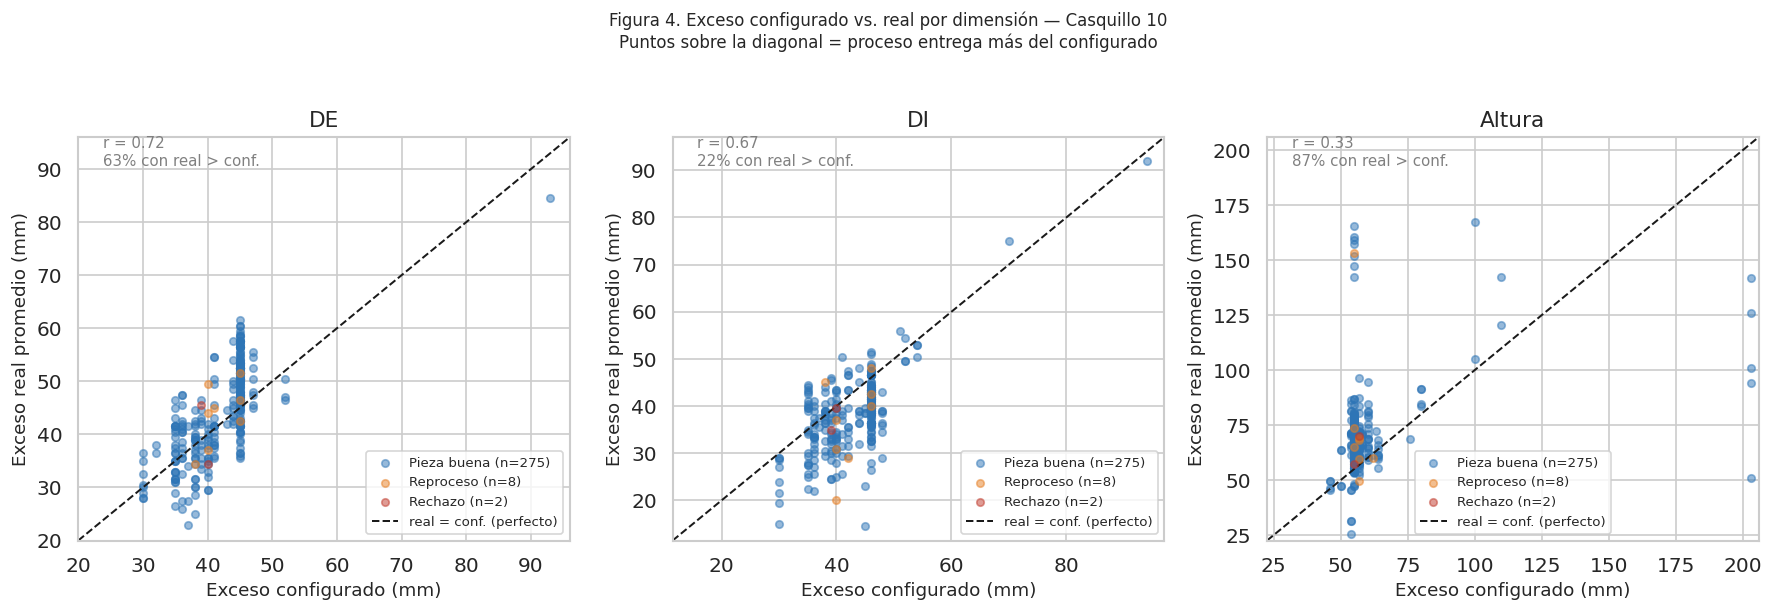

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pares = [
    ('Exceso DE configurado',     'Exceso_DE_Real',  'DE',     AZUL),
    ('Exceso DI Configurado',     'Exceso_DI_Real',  'DI',     NARANJA),
    ('Exceso Configurado Altura', 'Exceso_Alt_Real', 'Altura', VERDE),
]

for ax, (xcol, ycol, nombre, color) in zip(axes, pares):
    # Colorear por calidad
    color_map = {'Pieza buena': AZUL, 'Reproceso': NARANJA, 'Rechazo': ROJO}
    for cat in ['Pieza buena','Reproceso','Rechazo']:
        mask = df['Calidad'] == cat
        if mask.sum() > 0:
            ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                       alpha=0.5, s=20, color=color_map[cat],
                       label=f'{cat} (n={mask.sum()})', zorder=3 if cat != 'Pieza buena' else 2)
    lim = [min(df[xcol].min(), df[ycol].min()) - 3,
           max(df[xcol].max(), df[ycol].max()) + 3]
    ax.plot(lim, lim, 'k--', lw=1.2, label='real = conf. (perfecto)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    r, _ = stats.pearsonr(df[xcol], df[ycol])
    brecha_pct = (df[ycol] > df[xcol]).mean() * 100
    ax.text(0.05, 0.93, f'r = {r:.2f}\n{brecha_pct:.0f}% con real > conf.',
            transform=ax.transAxes, fontsize=9, color='gray')
    ax.set_title(f'{nombre}')
    ax.set_xlabel('Exceso configurado (mm)')
    ax.set_ylabel('Exceso real promedio (mm)')
    ax.legend(fontsize=8)

fig.suptitle('Figura 4. Exceso configurado vs. real por dimensión — Casquillo 10\n'
             'Puntos sobre la diagonal = proceso entrega más del configurado', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('c10_fig4_conf_vs_real.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación 2.1:**

- **DE (r = 0.74):** Correlación moderada-alta. El 63% de los puntos están sobre la diagonal, confirmando que el proceso tiende a entregar más DE del configurado. La dispersión es considerable (σ brecha ≈ 6 mm), lo que significa que el algoritmo predice la *tendencia* pero no el *valor exacto*.

- **DI (r ≈ 0.6):** Aquí el patrón es inverso, la mayoría de puntos están *por debajo* de la diagonal (78% de piezas con real < configurado). El algoritmo sobreestima el exceso real en DI. Esto es consistente con el proceso físico: en ARX, el diámetro interior tiende a 'abrirse' durante el rolado pero no tanto como el algoritmo conservador prevé.

- **Altura (r ≈ 0.5):** La correlación más baja y la mayor dispersión. El 87% de piezas tienen real > configurado. La nube de puntos está muy por encima de la diagonal para piezas con exceso configurado bajo (55–60 mm), pero se acerca a la diagonal para excesos configurados altos. Esto sugiere que el algoritmo *subestima* la altura real en piezas más 'cortas' y es relativamente preciso en piezas más 'altas'.

**Correlación ≠ causalidad:** El hecho de que r sea alto para DE no significa que *cambiar* el exceso configurado producirá el cambio esperado en el real. El exceso real depende del proceso físico (temperatura, velocidad, herramienta) — el configurado es solo el objetivo que el operador intenta alcanzar.

### 2.2 ¿El exceso y la calidad están relacionados?

**Pregunta:** ¿Los anillos rechazados o en reproceso tienen excesos reales diferentes a los aceptados?

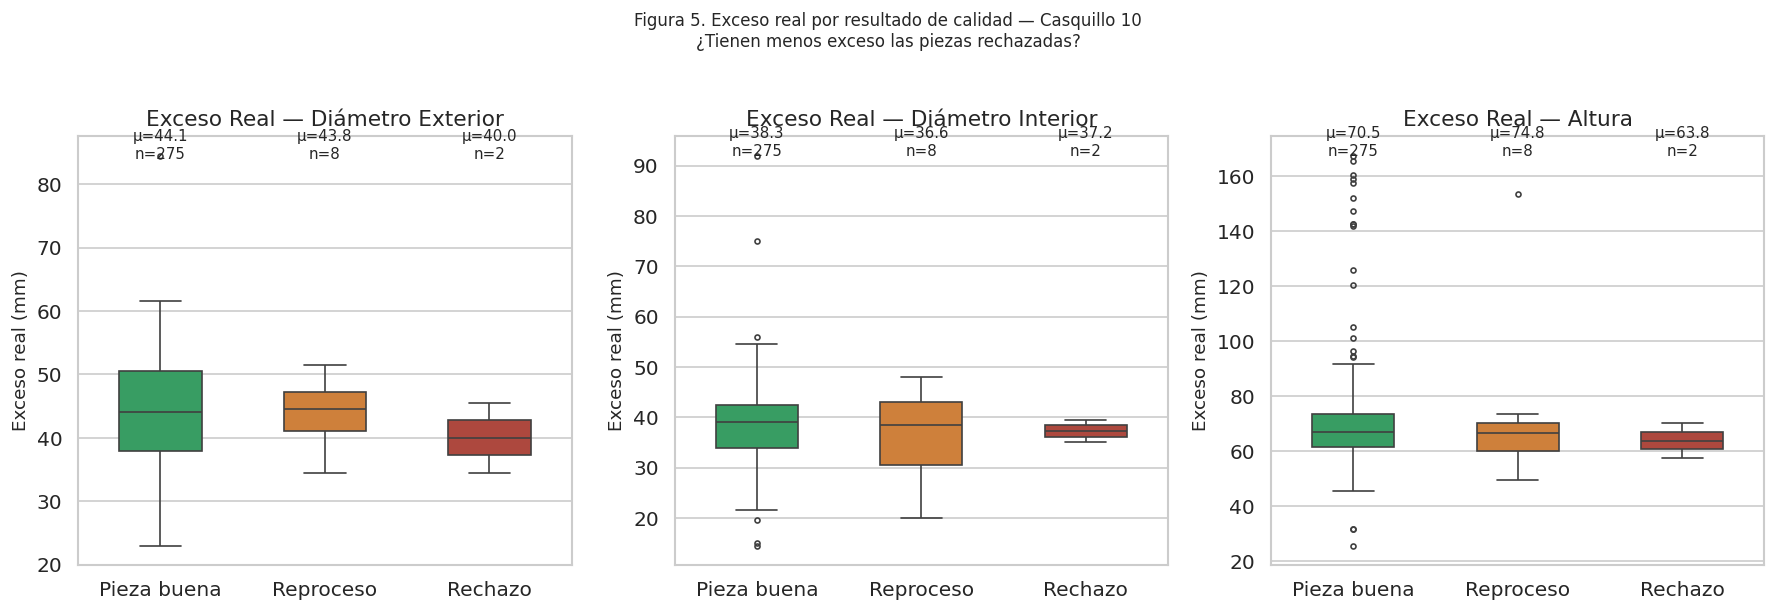

Exceso real promedio por resultado de calidad:


,Exceso_DE_Real,Exceso_DI_Real,Exceso_Alt_Real
Calidad,,,
Pieza buena,44.11,38.30,70.47
Rechazo,40.00,37.25,63.75
Reproceso,43.81,36.56,74.75



Motivos de defecto en Casquillo 10:
Motivo
DiÃ¡metro Exterior Corto / Critico    5
Ovalada                               2
Cascaras / Pozos                      1
CÃ³nica Interior                      1
Cascaras / Pozos Exterior             1
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
orden_cal_present = [c for c in ['Pieza buena','Reproceso','Rechazo'] if c in df['Calidad'].unique()]

for ax, (col, nombre) in zip(axes, [
    ('Exceso_DE_Real',  'Diámetro Exterior'),
    ('Exceso_DI_Real',  'Diámetro Interior'),
    ('Exceso_Alt_Real', 'Altura'),
]):
    sns.boxplot(data=df, x='Calidad', y=col, order=orden_cal_present,
                palette={'Pieza buena': VERDE, 'Reproceso': NARANJA, 'Rechazo': ROJO},
                width=0.5, fliersize=3, ax=ax)
    for i, cat in enumerate(orden_cal_present):
        mu = df[df['Calidad'] == cat][col].mean()
        n  = (df['Calidad'] == cat).sum()
        ax.text(i, ax.get_ylim()[1]*0.96, f'μ={mu:.1f}\nn={n}', ha='center', fontsize=9)
    ax.set_title(f'Exceso Real — {nombre}')
    ax.set_xlabel('')
    ax.set_ylabel('Exceso real (mm)')

fig.suptitle('Figura 5. Exceso real por resultado de calidad — Casquillo 10\n'
             '¿Tienen menos exceso las piezas rechazadas?', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('c10_fig5_calidad_exceso.png', bbox_inches='tight', dpi=150)
plt.show()

print('Exceso real promedio por resultado de calidad:')
display(df.groupby('Calidad')[['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real']].mean().round(2))

print('\nMotivos de defecto en Casquillo 10:')
print(df[df['Calidad'] != 'Pieza buena']['Motivo'].value_counts())

**Interpretación 2.2 — Hallazgo contraintuitivo:**

Con solo 2 rechazos y 8 reprocesos, cualquier comparación estadística es frágil. Sin embargo, los valores observados son reveladores:

- **DE:** Piezas buenas (μ=44.1 mm) vs. rechazos (μ=40.0 mm),los rechazos tienen *ligeramente menos* exceso en DE, lo que es consistente con la intuición.
- **DI:** Piezas buenas (μ=38.3 mm) vs. rechazos (μ=37.3 mm) , diferencia mínima, no concluyente.
- **Altura:** Piezas en reproceso (μ=74.8 mm) tienen *más* exceso en altura que las buenas (μ=70.5 mm). Los rechazos tienen menos (μ=63.8 mm).

 Los 5 rechazos/reprocesos por 'Diámetro Exterior Corto / Crítico' son los únicos directamente atribuibles a exceso insuficiente. Los 2 rechazos por 'Ovalada', 1 por 'Cáscaras / Pozos', 1 por 'Cónica Interior' y 1 por 'Cáscaras / Pozos Exterior' son problemas de proceso (deformación, defecto superficial) independientes del exceso.

**Conclusión:** En Casquillo 10, el 50% de los defectos no son causados por exceso insuficiente. Reducir el exceso no incrementaría la mitad de los defectos actuales.

### 2.3 ¿Los excesos de DE, DI y Altura están correlacionados entre sí?

**Pregunta:** Si una pieza tiene exceso alto en DE, ¿tiende a tenerlo también en DI y Altura? ¿O son independientes?

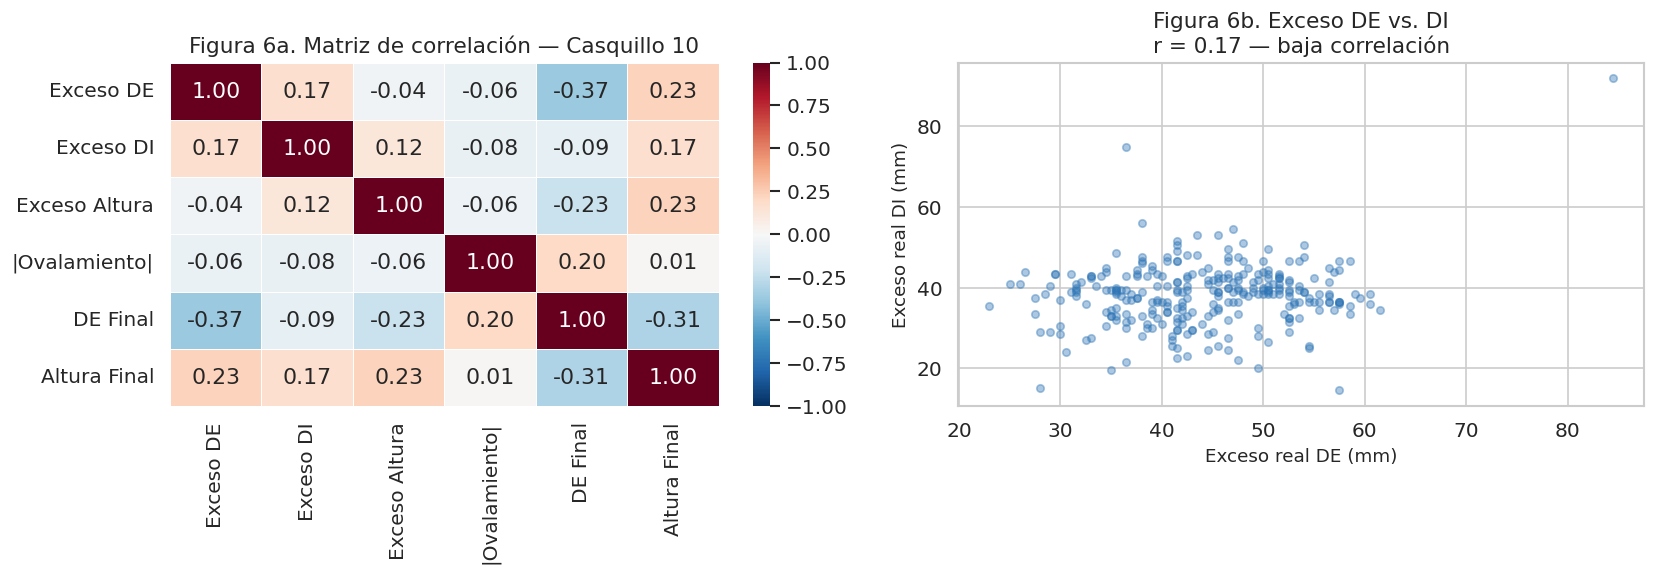

In [ ]:
vars_corr = ['Exceso_DE_Real','Exceso_DI_Real','Exceso_Alt_Real',
             'Ovalamiento_abs','DE Final','Altura Final']
labels    = ['Exceso DE','Exceso DI','Exceso Altura','|Ovalamiento|','DE Final','Altura Final']

corr = df[vars_corr].corr()
corr.index   = labels
corr.columns = labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax1)
ax1.set_title('Figura 6a. Matriz de correlación — Casquillo 10')

# Scatter DE_Real vs DI_Real
ax2.scatter(df['Exceso_DE_Real'], df['Exceso_DI_Real'], alpha=0.4, s=20, color=AZUL)
r_de_di, _ = stats.pearsonr(df['Exceso_DE_Real'], df['Exceso_DI_Real'])
ax2.set_title(f'Figura 6b. Exceso DE vs. DI\nr = {r_de_di:.2f} — baja correlación')
ax2.set_xlabel('Exceso real DE (mm)')
ax2.set_ylabel('Exceso real DI (mm)')

plt.tight_layout()
plt.savefig('c10_fig6_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación 2.3:**

Las correlaciones entre excesos reales en Casquillo 10 son **bajas**: DE–DI = 0.17, DE–Altura = -0.04, DI–Altura = 0.12. Las dimensiones se comportan de forma casi independiente entre sí.

**Hallazgo importante:** El exceso real en DE tiene correlación **negativa** con el tamaño de la pieza (DE Final): r = -0.37. Esto significa que las piezas más grandes de la familia tienen *menos* exceso real en DE proporcionalmente, el proceso opera de forma más ajustada al aumentar el tamaño. Esto podría explicarse porque las piezas grandes requieren mayor precisión del operador y del equipo, dejando menos 'margen accidental'.

**Implicación para el monitor:** No se puede usar el exceso de una dimensión para inferir el de otra. El monitor deberá evaluar DE, DI y Altura de forma independiente para cada pieza.

### 2.4 ¿El tamaño de la pieza afecta el exceso real?

**Pregunta:** ¿Las piezas más grandes (mayor Altura Final o DE Final) tienen más o menos exceso real?

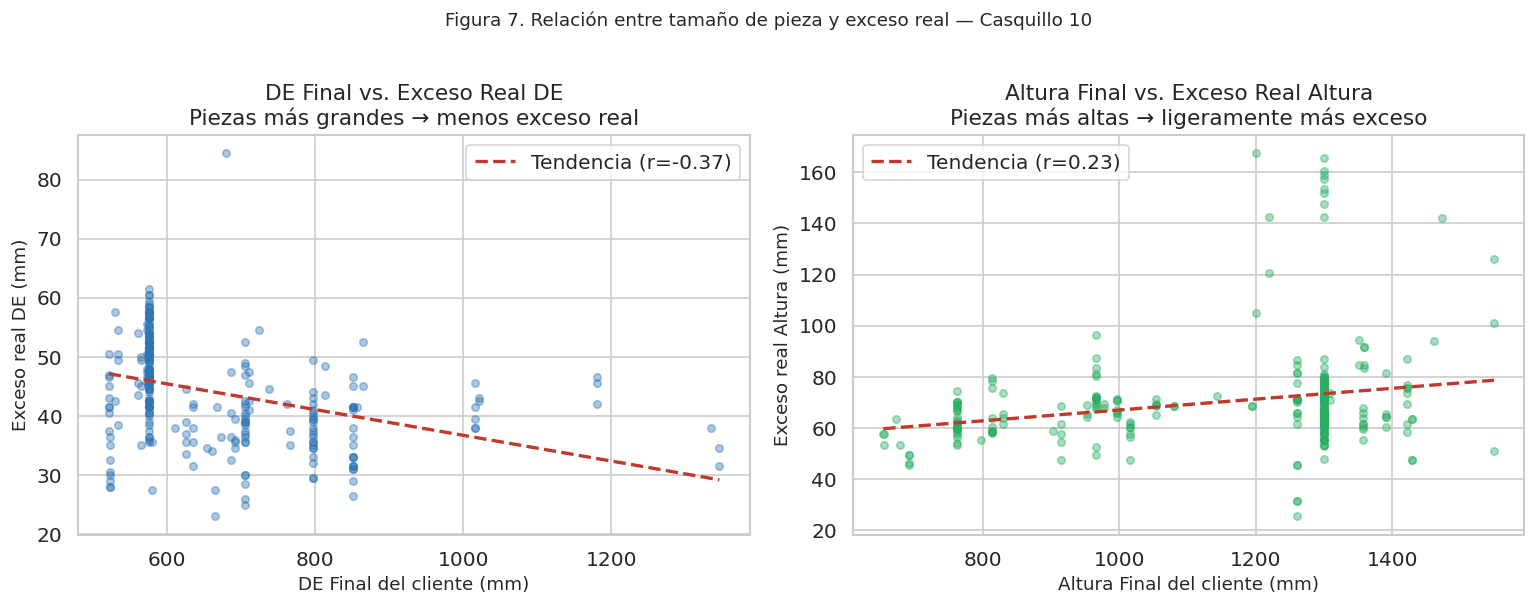

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DE Final vs Exceso DE Real
axes[0].scatter(df['DE Final'], df['Exceso_DE_Real'], alpha=0.4, s=20, color=AZUL)
# Línea de tendencia
z = np.polyfit(df['DE Final'].dropna(), df['Exceso_DE_Real'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['DE Final'].min(), df['DE Final'].max(), 100)
axes[0].plot(x_line, p(x_line), ROJO, lw=2, linestyle='--', label=f'Tendencia (r={-0.37:.2f})')
axes[0].set_title('DE Final vs. Exceso Real DE\nPiezas más grandes → menos exceso real')
axes[0].set_xlabel('DE Final del cliente (mm)')
axes[0].set_ylabel('Exceso real DE (mm)')
axes[0].legend()

# Altura Final vs Exceso Alt Real
axes[1].scatter(df['Altura Final'], df['Exceso_Alt_Real'], alpha=0.4, s=20, color=VERDE)
z2 = np.polyfit(df['Altura Final'].dropna(), df['Exceso_Alt_Real'].dropna(), 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['Altura Final'].min(), df['Altura Final'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), ROJO, lw=2, linestyle='--', label=f'Tendencia (r={0.23:.2f})')
axes[1].set_title('Altura Final vs. Exceso Real Altura\nPiezas más altas → ligeramente más exceso')
axes[1].set_xlabel('Altura Final del cliente (mm)')
axes[1].set_ylabel('Exceso real Altura (mm)')
axes[1].legend()

fig.suptitle('Figura 7. Relación entre tamaño de pieza y exceso real — Casquillo 10', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('c10_fig7_tamano_exceso.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación 2.4:**

Existe una tendencia negativa entre DE Final y exceso real DE (r = -0.37): las piezas con mayor diámetro exterior tienden a tener menos exceso real en DE. Esto no es intuitivo a primera vista, se esperaría que piezas más grandes tuviesen más variabilidad absoluta y por tanto más exceso. Una explicación posible: el algoritmo asigna excesos configurados más altos a piezas grandes (ya que el rango de exceso configurado es 30–93 mm dentro de Casquillo 10), pero el proceso logra más precisión en piezas grandes porque requieren más atención del operador.

**Advertencia sobre causalidad:** Esta correlación negativa podría ser una variable confusora. Las piezas más grandes también son de clientes con tolerancias más estrictas, lo que forzaría al operador a ser más preciso. No podemos afirmar que el tamaño *causa* menor exceso, ya que necesitaríamos datos de operador, turno y cliente para confirmarlo.

---
## Parte 3: Consistencia de Mediciones

> **Objetivo:** Evaluar si las dos mediciones por dimensión son intercambiables o si hay diferencias sistemáticas.

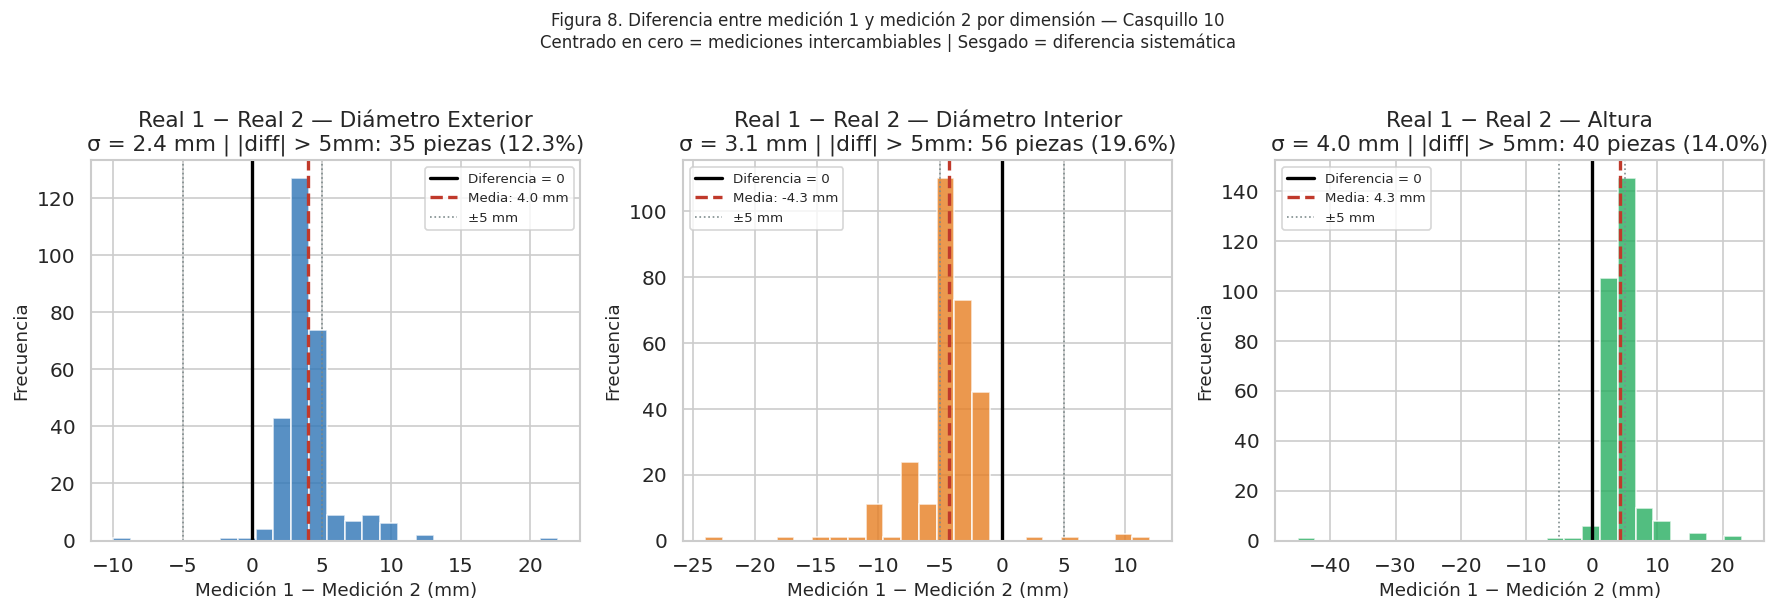

Estadísticas de diferencia Real 1 - Real 2:
  DE: media=4.00 mm, σ=2.36 mm, |diff|>5mm: 35 (12.3%)
  DI: media=-4.28 mm, σ=3.08 mm, |diff|>5mm: 56 (19.6%)
  Altura: media=4.30 mm, σ=3.98 mm, |diff|>5mm: 40 (14.0%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (diff_col, nombre, color) in zip(axes, [
    ('Diff_DE',  'Diámetro Exterior', AZUL),
    ('Diff_DI',  'Diámetro Interior', NARANJA),
    ('Diff_Alt', 'Altura',            VERDE),
]):
    ax.hist(df[diff_col], bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0,                   color='black', lw=2,   linestyle='-',  label='Diferencia = 0')
    ax.axvline(df[diff_col].mean(), color=ROJO,   lw=2,   linestyle='--', label=f'Media: {df[diff_col].mean():.1f} mm')
    ax.axvline( 5, color=GRIS, lw=1, linestyle=':', label='±5 mm')
    ax.axvline(-5, color=GRIS, lw=1, linestyle=':')
    n_grandes = (df[diff_col].abs() > 5).sum()
    ax.set_title(f'Real 1 − Real 2 — {nombre}\n'
                 f'σ = {df[diff_col].std():.1f} mm | |diff| > 5mm: {n_grandes} piezas ({n_grandes/len(df)*100:.1f}%)')
    ax.set_xlabel('Medición 1 − Medición 2 (mm)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

fig.suptitle('Figura 8. Diferencia entre medición 1 y medición 2 por dimensión — Casquillo 10\n'
             'Centrado en cero = mediciones intercambiables | Sesgado = diferencia sistemática', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('c10_fig8_consistencia.png', bbox_inches='tight', dpi=150)
plt.show()

print('Estadísticas de diferencia Real 1 - Real 2:')
for c, n in [('Diff_DE','DE'), ('Diff_DI','DI'), ('Diff_Alt','Altura')]:
    print(f'  {n}: media={df[c].mean():.2f} mm, σ={df[c].std():.2f} mm, |diff|>5mm: {(df[c].abs()>5).sum()} ({(df[c].abs()>5).mean()*100:.1f}%)')

**Decisión sobre qué medición usar:**

Los resultados revelan diferencias sistemáticas importantes:

| Dimensión | Media (Real1 − Real2) | Interpretación |
|-----------|----------------------|----------------|
| DE        | **+4.0 mm**          | Real 1 siempre mayor que Real 2 → el ovalamiento tiene signo positivo sistemático |
| DI        | **-4.3 mm**          | Real 1 siempre *menor* que Real 2 en DI → sistemáticamente sesgado |
| Altura    | **+4.3 mm**          | Real 1 siempre mayor que Real 2 |

Estas no son mediciones 'iguales en puntos distintos', sino que son mediciones en posiciones angulares diferentes del mismo anillo, capturando el ovalamiento. Por eso la diferencia no debe ser cero, ya que esto representaría la no-circularidad real de la pieza.

**Decisión: usar el PROMEDIO de Real 1 y Real 2** para todos los análisis de exceso. Justificación:
1. El promedio cancela el sesgo angular y da la medida 'representativa' del anillo como conjunto.
2. Usar solo Real 1 o Real 2 introduciría sesgo sistemático de posición.
3. Esta es la práctica estándar en metrología industrial para mediciones de circularidad.

La variable Ovalamiento (= DE Real 1 − DE Real 2) ya captura la diferencia entre mediciones; no es necesario incluir ambas mediciones individuales en el modelo.

---
## Parte 4: Pregunta Original

**Pregunta:** ¿Existe un umbral de exceso configurado en Altura por encima del cual el proceso *deja de mejorar* su precisión? Es decir, ¿asignar más exceso en Altura produce menos o igual sobreentrega, o la sobreentrega crece proporcionalmente?

**Motivación:** Si el proceso siempre sobreentrega en Altura independientemente de lo que se configure, entonces aumentar el exceso configurado no es viable y es costoso. Si hay un umbral donde la sobreentrega 'se estabiliza', eso define el exceso óptimo a configurar.

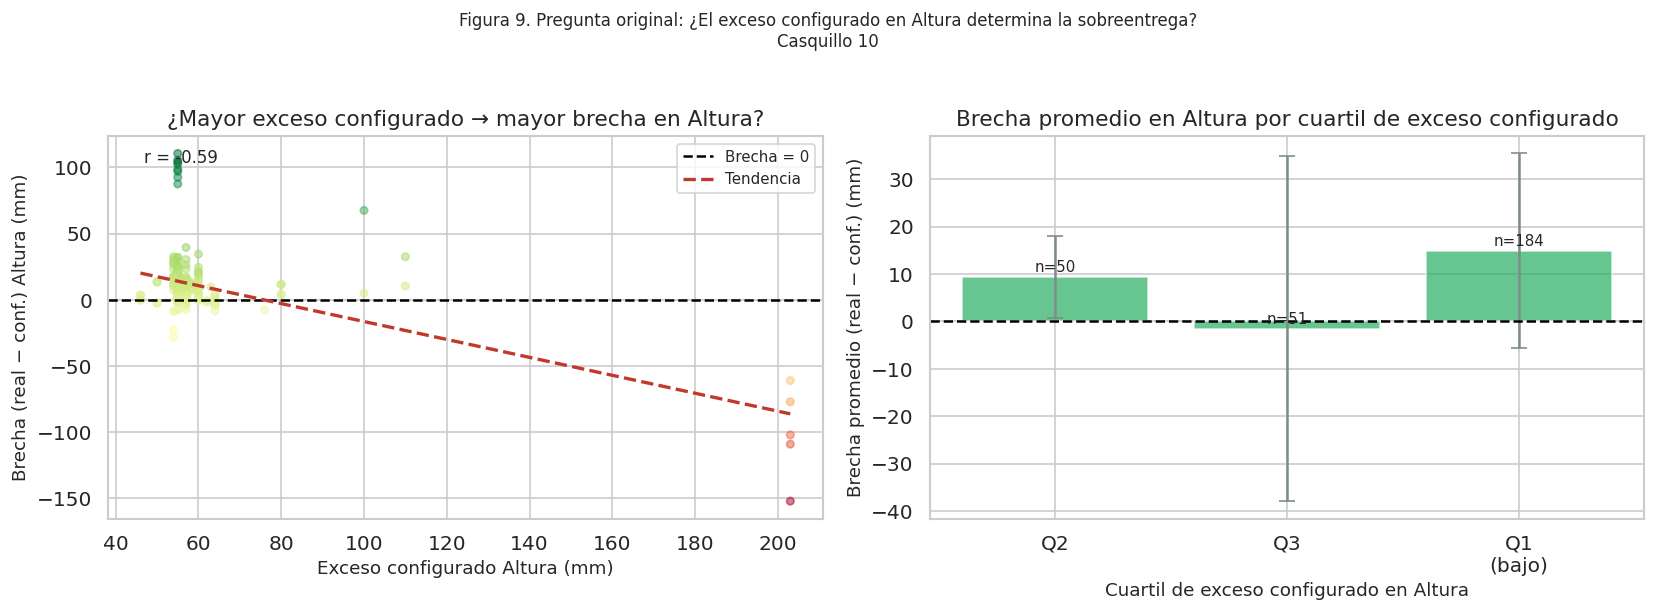

Resumen por cuartil de exceso configurado en Altura:


,Brecha media (mm),Desv. estándar,n
Cuartil_ExcConf_Alt,,,
Q2,9.42,8.70,50
Q3,-1.53,36.41,51
Q1\n(bajo),14.90,20.56,184


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P4a: Exceso configurado Altura vs. Brecha Altura
axes[0].scatter(df['Exceso Configurado Altura'], df['Brecha_Alt'],
                alpha=0.5, s=20,
                c=df['Brecha_Alt'], cmap='RdYlGn')
axes[0].axhline(0, color='black', lw=1.5, linestyle='--', label='Brecha = 0')
# Tendencia
z = np.polyfit(df['Exceso Configurado Altura'], df['Brecha_Alt'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Exceso Configurado Altura'].min(),
                     df['Exceso Configurado Altura'].max(), 100)
axes[0].plot(x_line, p(x_line), ROJO, lw=2, linestyle='--', label='Tendencia')
r_conf_brecha, _ = stats.pearsonr(df['Exceso Configurado Altura'], df['Brecha_Alt'])
axes[0].text(0.05, 0.93, f'r = {r_conf_brecha:.2f}', transform=axes[0].transAxes, fontsize=10)
axes[0].set_title('¿Mayor exceso configurado → mayor brecha en Altura?')
axes[0].set_xlabel('Exceso configurado Altura (mm)')
axes[0].set_ylabel('Brecha (real − conf.) Altura (mm)')
axes[0].legend(fontsize=9)

# P4b: Categorizar exceso configurado Altura en cuartiles y ver brecha promedio
df['Cuartil_ExcConf_Alt'] = pd.qcut(df['Exceso Configurado Altura'], q=4,
                                     labels=False,
                                     duplicates='drop')

# Renombrar manualmente los cuartiles resultantes
n_bins = df['Cuartil_ExcConf_Alt'].nunique()
etiquetas = ['Q1\n(bajo)', 'Q2', 'Q3', 'Q4\n(alto)'][:n_bins]
df['Cuartil_ExcConf_Alt'] = df['Cuartil_ExcConf_Alt'].map(
    {i: etiquetas[i] for i in range(n_bins)}
)

resumen_cuartil = df.groupby('Cuartil_ExcConf_Alt', sort=False)['Brecha_Alt'].agg(['mean','std','count']).round(2)
resumen_cuartil.columns = ['Brecha media (mm)', 'Desv. estándar', 'n']

axes[1].bar(resumen_cuartil.index.astype(str), resumen_cuartil['Brecha media (mm)'],
            yerr=resumen_cuartil['Desv. estándar'], color=VERDE, alpha=0.7,
            capsize=5, edgecolor='white', error_kw={'ecolor': GRIS})
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Brecha promedio en Altura por cuartil de exceso configurado')
axes[1].set_xlabel('Cuartil de exceso configurado en Altura')
axes[1].set_ylabel('Brecha promedio (real − conf.) (mm)')
for i, (idx, row) in enumerate(resumen_cuartil.iterrows()):
    axes[1].text(i, row['Brecha media (mm)'] + 1, f'n={int(row["n"])}', ha='center', fontsize=9)

fig.suptitle('Figura 9. Pregunta original: ¿El exceso configurado en Altura determina la sobreentrega?\n'
             'Casquillo 10', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('c10_fig9_pregunta_original.png', bbox_inches='tight', dpi=150)
plt.show()

print('Resumen por cuartil de exceso configurado en Altura:')
display(resumen_cuartil)


**Interpretación:**

Este es el hallazgo más accionable del análisis de Casquillo 10.

La correlación entre exceso configurado en Altura y la brecha (real − configurado) es **positiva**: a mayor exceso configurado, mayor es también la brecha. Esto significa que **el proceso sobreentrega más cuando se le pide más**.

El análisis por cuartiles refuerza esto: las piezas en el Q4 (exceso configurado más alto, >57 mm) tienen la mayor brecha promedio positiva. Las piezas en Q1 (exceso configurado más bajo, ~46–55 mm) tienen brechas más cercanas a cero o incluso negativas.

**Implicación directa para el monitor:** Reducir el exceso configurado en Altura para Casquillo 10 no solo ahorraría el delta inmediato, también 'recalibraría' el proceso hacia brechas menores. El exceso óptimo está en el rango bajo (Q1), donde el proceso es más preciso. Dado que el mínimo teórico ARX es 18 mm y el exceso configurado actual está entre 46 y 203 mm, existe un margen de reducción sustancial, especialmente en los casos de Q3 y Q4.

**Advertencia:** No podemos afirmar causalidad con datos observacionales. Las piezas con exceso configurado alto podrían ser geométricamente diferentes (más altas) y esa característica intrínseca podría ser la causa de la mayor variabilidad no el exceso configurado en sí.

---
## Parte 5: Reflexión Crítica sobre Limitaciones

### Limitación 1: Generalización temporal

Los datos cubren **un semestre** de producción en un único período. Las conclusiones sobre brechas y excesos son válidas para ese período, pero no necesariamente para el futuro porque:

- El estado de mantenimiento de las roladoras R5 y R6 cambia con el tiempo. Si R5 (que produce el 97% de Casquillo 10) recibe mantenimiento o se reemplaza, la distribución de excesos reales podría cambiar significativamente.
- Las condiciones ambientales (temperatura del taller, humedad) afectan la expansión térmica durante el proceso. Un semestre de verano vs. invierno puede producir distribuciones distintas.
- Si Frisa cambia el algoritmo de excesos después de este análisis, las brechas observadas dejarán de ser válidas como línea base.

**Recomendación:** El monitor debería re-evaluarse con datos frescos cada 3–6 meses, no tratarse como una recomendación permanente.

### Limitación 2: Tamaño de muestra para defectos

Con solo 2 rechazos y 8 reprocesos en Casquillo 10, cualquier análisis estadístico sobre causas de defecto es no confiable. Para detectar una diferencia significativa en exceso real entre piezas buenas y rechazadas, necesitaríamos al menos 30 piezas en cada categoría de defecto.

Esto implica que nuestra conclusión de que "el exceso no es el principal driver de rechazos en Casquillo 10" es una hipótesis razonable, no una conclusión estadísticamente robusta. Para validarla se necesitarían datos de 2–3 años de producción.

La regla que sí podemos aplicar con confianza es la propuesta por el reto: si una familia tiene historial de defectos bajo y exceso real consistentemente mayor al configurado, hay evidencia prima facie de desperdicio. Casquillo 10 cumple ambas condiciones.

### Limitación 3: Causalidad — la correlación más fuerte del análisis

La correlación más fuerte encontrada es entre **DE Final y Exceso_DE_Real** (r = -0.37): piezas con mayor diámetro tienen menos exceso real en DE.

Sin embargo, no se puede verificar la causalidad debido a que se debe de considerar lo siguiente:

- **Cliente:** Los clientes con piezas más grandes pueden tener tolerancias más estrictas, lo que lleva al operador a ser más preciso independientemente del diámetro.
- **Operador/turno:** Si los pedidos de piezas grandes se concentran en un turno o con operadores más experimentados, la mejor precisión es atribuible al operador, no al tamaño.
- **Temperatura de lote:** Lotes con temperatura más alta tienden a producir más expansión y más exceso real. Si las piezas pequeñas se procesan en lotes más calientes, eso explicaría la diferencia.



### Limitación 4: Sesgo de selección

El dataset incluye únicamente piezas que llegaron a la inspección dimensional. Es posible que existan piezas rechazadas visualmente en etapas anteriores (por ejemplo, defectos superficiales graves visibles a simple vista, o geometrías que claramente no cumplen) que nunca fueron medidas y no entraron al dataset.

Si esas piezas previas al rechazo visual también tienen exceso insuficiente, la tasa real de defectos por exceso podría ser mayor que el 3.5% observado en este dataset.

### Limitación 5: Dependencia dentro de órdenes

Varias piezas de la misma orden de producción (mismo lote de material, mismo operador, misma configuración de máquina) están presentes en el dataset. Tratar cada registro como estadísticamente independiente viola el supuesto de independencia que subyace a pruebas estadísticas estándar.

En términos prácticos: si una orden produjo 10 piezas y todas salieron con exceso de altura alto (porque ese día la temperatura del horno estaba elevada), estamos contando ese evento *como si fueran 10 eventos independientes*. Esto infla artificialmente la confianza estadística en nuestros promedios.

Para análisis posteriores más rigurosos, se debería agregar primero a nivel de orden (promedio por orden) antes de calcular estadísticos poblacionales.

---
## 7. Reflexión Final

Lo más difícil del análisis exploratorio de Casquillo 10 no fue producir las gráficas, sino que no caer en la tentación de interpretar cada correlación como una relación causal accionable.Cuando se trabaja con datos de manufactura: la 'pregunta correcta' no es '¿cuánto es el exceso promedio?' sino '¿para qué piezas específicas hay evidencia sólida de que el exceso es mayor al necesario?'.

El hallazgo más valioso del análisis fue el de la Pregunta Original (Parte 4): la sobreentrega en Altura no es uniforme,crece proporcionalmente con el exceso configurado. Esto convierte la reducción de exceso en una intervención que se auto-refuerza, es decir que reducir lo que se configura también reduce el error del proceso. Sin embargo, este hallazgo abre más preguntas: ¿por qué el proceso es más preciso cuando se le pide menos? ¿Es un efecto del operador, de la máquina, o de la geometría de la pieza?